# Experiment 7.3.2 — Affine Probe Bridge

Analysis-only notebook. It reads finalized Exp7.3.2 artifacts and does not train models or submit jobs.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=Path.cwd()):
    cur = start.resolve()
    for candidate in (cur, *cur.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_3_2_affine_probe_bridge' / 'affine_probe_bridge_v1'
manifest = json.loads((ROOT / 'manifest.json').read_text())
runs = pd.read_csv(ROOT / 'method_runs.csv')
summary = pd.read_csv(ROOT / 'method_summary.csv')
contrasts = pd.read_csv(ROOT / 'contrast_summary.csv')
p7 = pd.read_csv(ROOT / 'p7_legacy_reproduction.csv')
manifest


{'C_grid': [0.001, 0.01, 0.1, 1.0, 10.0],
 'architecture': '234x234',
 'backbone_objectives': ['tsce', 'wcce'],
 'cases': [{'aggregation': 'mean',
   'bias': False,
   'center': False,
   'key': 'P0_mean_scale_no_center_no_bias'},
  {'aggregation': 'mean',
   'bias': True,
   'center': False,
   'key': 'P1_mean_scale_no_center_bias'},
  {'aggregation': 'mean',
   'bias': False,
   'center': True,
   'key': 'P2_mean_scale_center_no_bias'},
  {'aggregation': 'mean',
   'bias': True,
   'center': True,
   'key': 'P3_mean_scale_center_bias'},
  {'aggregation': 'wholecount',
   'bias': False,
   'center': False,
   'key': 'P4_wholecount_scale_no_center_no_bias'},
  {'aggregation': 'wholecount',
   'bias': True,
   'center': False,
   'key': 'P5_wholecount_scale_no_center_bias'},
  {'aggregation': 'wholecount',
   'bias': False,
   'center': True,
   'key': 'P6_wholecount_scale_center_no_bias'},
  {'aggregation': 'wholecount',
   'bias': True,
   'center': True,
   'key': 'P7_wholecount_scal

## Mean test balanced accuracy by bridge case

P0 is the most deployment-like rate/scale-only/bias-free probe. P7 reproduces the legacy whole-count StandardScaler + intercept probe.


In [2]:
display_cols = [
    'backbone_objective', 'case', 'aggregation', 'center', 'bias',
    'test_ba_mean', 'test_ba_std',
    'legacy_l2_wholecount_probe_test_ba_mean',
    'test_ba_minus_legacy_pp_mean',
    'effective_intercept_l2_mean',
]
summary[display_cols].sort_values(['backbone_objective', 'case'])


,backbone_objective,case,aggregation,center,bias,test_ba_mean,test_ba_std,legacy_l2_wholecount_probe_test_ba_mean,test_ba_minus_legacy_pp_mean,effective_intercept_l2_mean
0,tsce,P0_mean_scale_no_center_no_bias,mean,False,False,0.536461,0.028186,0.596121,-5.966094,0.000000
1,tsce,P1_mean_scale_no_center_bias,mean,False,True,0.551992,0.011492,0.596121,-4.412971,3.572803
2,tsce,P2_mean_scale_center_no_bias,mean,True,False,0.560710,0.009799,0.596121,-3.541158,3.682595
3,tsce,P3_mean_scale_center_bias,mean,True,True,0.555720,0.016965,0.596121,-4.040196,3.801402
4,tsce,P4_wholecount_scale_no_center_no_bias,wholecount,False,False,0.551035,0.023676,0.596121,-4.508663,0.000000
5,tsce,P5_wholecount_scale_no_center_bias,wholecount,False,True,0.593596,0.029940,0.596121,-0.252525,5.386953
6,tsce,P6_wholecount_scale_center_no_bias,wholecount,True,False,0.596886,0.020278,0.596121,0.076451,5.401496
7,tsce,P7_wholecount_scale_center_bias,wholecount,True,True,0.596121,0.031797,0.596121,0.000000,5.391647
8,wcce,P0_mean_scale_no_center_no_bias,mean,False,False,0.548810,0.017291,0.586273,-3.746369,0.000000
9,wcce,P1_mean_scale_no_center_bias,mean,False,True,0.556776,0.010088,0.586273,-2.949782,3.470083


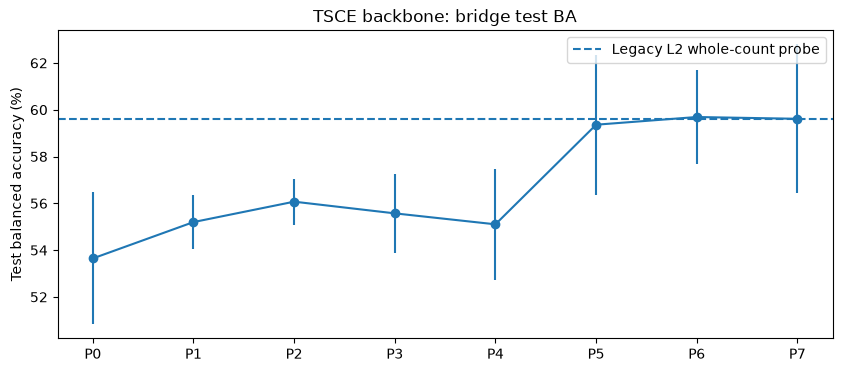

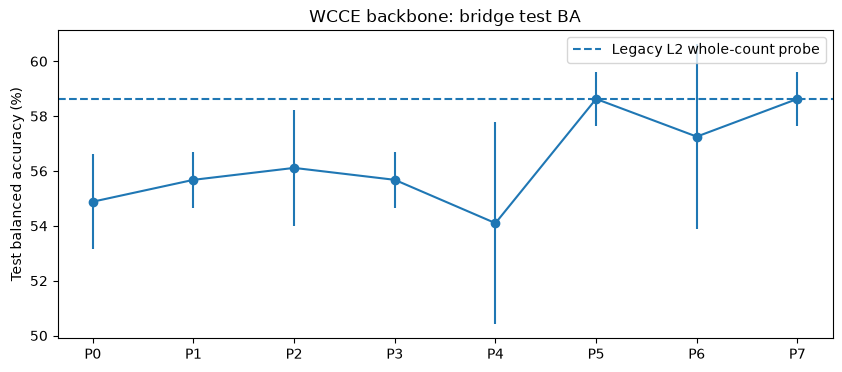

In [3]:
case_order = [f'P{i}' for i in range(8)]
tmp = summary.copy()
tmp['short_case'] = tmp['case'].str.extract(r'^(P\d)')[0]
for backbone in manifest['backbone_objectives']:
    view = tmp[tmp.backbone_objective == backbone].set_index('short_case').reindex(case_order)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.errorbar(case_order, 100 * view['test_ba_mean'], yerr=100 * view['test_ba_std'], marker='o')
    legacy = 100 * view['legacy_l2_wholecount_probe_test_ba_mean'].iloc[0]
    ax.axhline(legacy, linestyle='--', label='Legacy L2 whole-count probe')
    ax.set_title(f'{backbone.upper()} backbone: bridge test BA')
    ax.set_ylabel('Test balanced accuracy (%)')
    ax.legend()
    plt.show()


## Factor contrasts


In [4]:
contrasts.sort_values(['backbone_objective', 'contrast'])


,contrast,backbone_objective,delta_pp_count,delta_pp_mean,delta_pp_std
0,aggregation_effect_center_bias,tsce,3,4.040196,1.986467
2,aggregation_effect_center_no_bias,tsce,3,3.617609,1.914435
4,aggregation_effect_no_center_bias,tsce,3,4.160446,1.882506
6,aggregation_effect_no_center_no_bias,tsce,3,1.457431,2.308458
8,full_bridge_P7_minus_P0,tsce,3,5.966094,0.363257
10,mean_bias_effect_centered,tsce,3,-0.499038,0.803383
12,mean_bias_effect_no_center,tsce,3,1.553123,1.779585
14,mean_center_effect_no_bias,tsce,3,2.424936,1.907905
16,mean_center_effect_with_bias,tsce,3,0.372775,0.645666
18,wholecount_bias_effect_centered,tsce,3,-0.076451,2.520647


## P7 legacy reproduction check

The absolute test-BA delta should be zero or numerically negligible if the bridge protocol reproduces the stored Exp7.3 probe under the same sklearn environment.


In [5]:
p7


,seed,backbone_objective,selected_C,test_ba,legacy_l2_wholecount_probe_test_ba,p7_abs_test_ba_delta
0,11,tsce,0.01,0.615174,0.615174,0.0
1,23,tsce,0.10,0.559415,0.559415,0.0
2,37,tsce,0.10,0.613776,0.613776,0.0
3,11,wcce,0.01,0.575830,0.575830,0.0
4,23,wcce,0.01,0.587870,0.587870,0.0
5,37,wcce,0.01,0.595121,0.595121,0.0


## Effective affine offset

This diagnostic separates explicit intercept magnitude from the offset induced by feature centering.


In [6]:
affine_cols = [
    'backbone_objective', 'case',
    'explicit_intercept_l2_mean', 'centering_offset_l2_mean',
    'effective_intercept_l2_mean', 'effective_intercept_span_mean',
]
summary[affine_cols].sort_values(['backbone_objective', 'case'])


,backbone_objective,case,explicit_intercept_l2_mean,centering_offset_l2_mean,effective_intercept_l2_mean,effective_intercept_span_mean
0,tsce,P0_mean_scale_no_center_no_bias,0.000000,0.000000,0.000000,0.000000
1,tsce,P1_mean_scale_no_center_bias,3.572803,0.000000,3.572803,3.549523
2,tsce,P2_mean_scale_center_no_bias,0.000000,3.682595,3.682595,3.830866
3,tsce,P3_mean_scale_center_bias,2.148058,5.334469,3.801402,4.022674
4,tsce,P4_wholecount_scale_no_center_no_bias,0.000000,0.000000,0.000000,0.000000
5,tsce,P5_wholecount_scale_no_center_bias,5.386953,0.000000,5.386953,4.633592
6,tsce,P6_wholecount_scale_center_no_bias,0.000000,5.401496,5.401496,4.762826
7,tsce,P7_wholecount_scale_center_bias,2.030852,6.904466,5.391647,4.679387
8,wcce,P0_mean_scale_no_center_no_bias,0.000000,0.000000,0.000000,0.000000
9,wcce,P1_mean_scale_no_center_bias,3.470083,0.000000,3.470083,3.093764
